In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd




In [ ]:
df = pd.read_csv("/content/Quality.csv")


In [ ]:
df

,Service Quality,Value
0,Very Poor,45000
1,Poor,50000
2,Fair,60000
3,Good,80000
4,Very Good,110000
5,Excellent,150000
6,Outstanding,200000
7,Elite,300000
8,World-Class,500000
9,Legendary,1000000


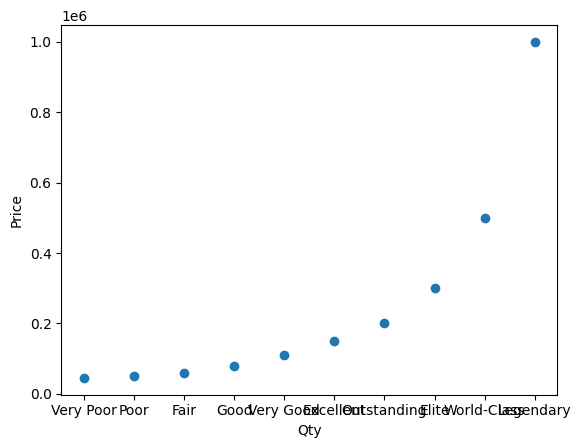

In [ ]:
plt.scatter(df['Service Quality'],df['Value'])
plt.xlabel("Qty")
plt.ylabel("Price")
plt.show()

In [ ]:
df["Service Quality"].unique()

array(['Very Poor', 'Poor', 'Fair', 'Good', 'Very Good', 'Excellent',
       'Outstanding', 'Elite', 'World-Class', 'Legendary'], dtype=object)

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

In [ ]:
Encoder=OrdinalEncoder(categories=[['Very Poor', 'Poor', 'Fair', 'Good', 'Very Good', 'Excellent','Outstanding', 'Elite', 'World-Class', 'Legendary']])

In [ ]:
df[['Service Quality']]=Encoder.fit_transform(df[['Service Quality']])

In [ ]:
df

,Service Quality,Value
0,0.0,45000
1,1.0,50000
2,2.0,60000
3,3.0,80000
4,4.0,110000
5,5.0,150000
6,6.0,200000
7,7.0,300000
8,8.0,500000
9,9.0,1000000


#split data to X , Y

In [ ]:
x=df.drop("Value",axis=1)
y=df["Value"]

In [ ]:
x

,Service Quality
0,0.0
1,1.0
2,2.0
3,3.0
4,4.0
5,5.0
6,6.0
7,7.0
8,8.0
9,9.0


In [ ]:
y

,Value
0,45000
1,50000
2,60000
3,80000
4,110000
5,150000
6,200000
7,300000
8,500000
9,1000000


#split Data Train , Test

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state= 35)

In [ ]:
from sklearn.linear_model import LinearRegression
Model = LinearRegression()
Model.fit(x_train, y_train)
y_pred =Model.predict(x_test)

#Draw Train Data

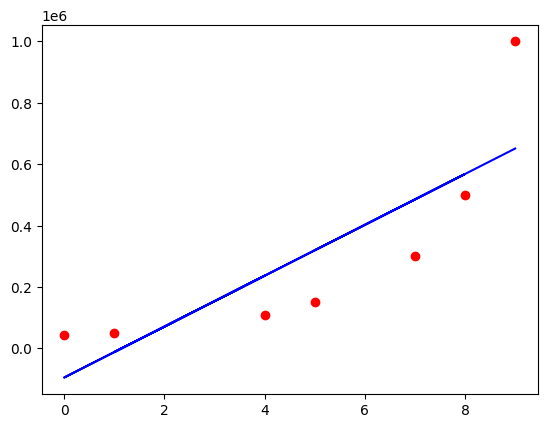

In [ ]:
plt.scatter(x_train,y_train,color='red')
plt.plot(x_train,Model.predict(x_train),color='blue')
plt.show()

#Draw Test Data

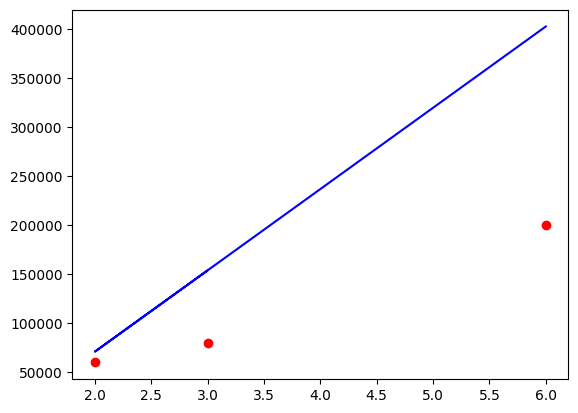

In [ ]:
plt.scatter(x_test,y_test,color='red')
plt.plot(x_test, Model.predict(x_test), color='blue')
plt.show()

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
poly_reg = PolynomialFeatures(degree = 5)

In [ ]:
X_poly = poly_reg.fit_transform(x_train)

In [ ]:
x_train

,Service Quality
5,5.0
8,8.0
0,0.0
4,4.0
1,1.0
7,7.0
9,9.0


In [ ]:
X_poly

array([[1.0000e+00, 5.0000e+00, 2.5000e+01, 1.2500e+02, 6.2500e+02,
        3.1250e+03],
       [1.0000e+00, 8.0000e+00, 6.4000e+01, 5.1200e+02, 4.0960e+03,
        3.2768e+04],
       [1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00],
       [1.0000e+00, 4.0000e+00, 1.6000e+01, 6.4000e+01, 2.5600e+02,
        1.0240e+03],
       [1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00,
        1.0000e+00],
       [1.0000e+00, 7.0000e+00, 4.9000e+01, 3.4300e+02, 2.4010e+03,
        1.6807e+04],
       [1.0000e+00, 9.0000e+00, 8.1000e+01, 7.2900e+02, 6.5610e+03,
        5.9049e+04]])

In [ ]:
from sklearn.linear_model import LinearRegression

poly_model = LinearRegression()
poly_model.fit(X_poly, y_train)

LinearRegression()

#Test

In [ ]:
X_test_poly = poly_reg.transform(x_test)

In [ ]:
x_test

,Service Quality
6,6.0
2,2.0
3,3.0


In [ ]:
X_test_poly

array([[1.000e+00, 6.000e+00, 3.600e+01, 2.160e+02, 1.296e+03, 7.776e+03],
       [1.000e+00, 2.000e+00, 4.000e+00, 8.000e+00, 1.600e+01, 3.200e+01],
       [1.000e+00, 3.000e+00, 9.000e+00, 2.700e+01, 8.100e+01, 2.430e+02]])

In [ ]:
y_pred_poly = poly_model.predict(X_test_poly)

#Evaluation

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

print("MSE =", mean_squared_error(y_test, y_pred_poly))
print("R2 =", r2_score(y_test, y_pred_poly))

MSE = 148828097.52058458
R2 = 0.9610624163463587
